# RWA oscillators do not follow a Boltzmann distribution????

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import diffrax
import matplotlib.pyplot as plt
from functools import partial

from diffrax import ControlTerm, MultiTerm, ODETerm, PIDController

jax.config.update("jax_enable_x64", True)

## Setup Problem

In [2]:
# ----------------------------
# 1. Define Parameters
# ----------------------------


# Physical Constants and Parameters
M1 = 1.0
M2 = 1.0

w1 = 5.0          # Natural frequency of oscillator 1 (rad/s)
w2 = 5.0          # Natural frequency of oscillator 2 (rad/s)

wp1 = 2*(w1+0.0)  # Driving frequency for oscillator 1 (rad/s)
wp2 = 2*(w2+0.0)  # Driving frequency for oscillator 2 (rad/s)

period1 = 2*jnp.pi/w1
period2 = 2*jnp.pi/w2

Fp1 = 5.0        # Amplitude of the wp driving for oscillator 1
Fp2 = 5.00         # Amplitude of the wp driving for oscillator 2

Q1 = 500.0       # Quality factor for oscillator 1
Q2 = 500.0       # Quality factor for oscillator 2

GAMMA1 = w1/(2*Q1)
GAMMA2 = w2/(2*Q2)

gamma1 = 1000.    # Nonlinearity coefficient for oscillator 1 (Duffing term)
gamma2 = 1000.    # Nonlinearity coefficient for oscillator 2 (Duffing term)

c = 0*.1


k_B = 1.0             # Boltzmann's constant (arbitrary units for simulation)
T = .005             # Temperature (K)
    # Noise strength

# Simulation Parameters
t0 = 0.0  
num_periods = 100000# Start time
period = 2*jnp.pi/w1
t1 = num_periods*period
dt0 = period/1000
num_pts_per_period = 100
ts_dim = jnp.linspace(t0, t1, 10000)
saveat = diffrax.SaveAt(ts=ts_dim)

y0_QP = jnp.array([0, 0, 0, 0])


CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [3]:
def Hamiltonian(Q1, P1, Q2, P2, args):
    dw = wp1/2 - w1  # detuning term
    
    # Parameters of the Hidden oscillator
    gamma_h, wp_h, Fp_h = args
    
    # Single oscillator terms (for both oscillators)
    H1 = 3*gamma1/(16*wp1) * (Q1**2 + P1**2)**2 + dw/2 *(Q1**2 - P1**2) + Fp1/(4*M1*wp1) * (P1**2 - Q1**2)
    H2 = 3*gamma_h/(16*wp_h) * (Q2**2 + P2**2)**2 + dw/2 *(Q2**2 - P2**2) + Fp_h/(4*M2*wp_h) * (P2**2 - Q2**2)

    # Coupling term
    H_coupling = c/4 * ((Q1 - Q2)**2 + (P1 - P2)**2)
    
    return H1 + H2 + H_coupling


def drift_QP_fn(t, state, args):
    """
    Drift function for the RWA equations
    """
    Q1, P1, Q2, P2 = state  # Unpack all state variables
    
    # Calculate gradients of Hamiltonian for both oscillators
    dQ1dt =  jax.grad(Hamiltonian, 1)(Q1, P1, Q2, P2, args) - GAMMA1*Q1
    dP1dt = -jax.grad(Hamiltonian, 0)(Q1, P1, Q2, P2, args) - GAMMA1*P1
    dQ2dt =  jax.grad(Hamiltonian, 3)(Q1, P1, Q2, P2, args) - GAMMA2*Q2
    dP2dt = -jax.grad(Hamiltonian, 2)(Q1, P1, Q2, P2, args) - GAMMA2*P2
    
    return jnp.array([dQ1dt, dP1dt, dQ2dt, dP2dt])



def diffusion_QP_fn(t, state, args):
    """
    Diffusion matrix for Q and P equations for two coupled oscillators.
    Returns a 4x4 matrix with noise terms for both oscillators.
    """
    # Noise strength for oscillator 1
    noise_strength_QP1 = jnp.sqrt(2*GAMMA1*k_B * T/(M1*w1**2))
    # Noise strength for oscillator 2  
    noise_strength_QP2 = jnp.sqrt(2*GAMMA2*k_B * T/(M2*w2**2))
    
    # Create 4x4 matrix for both oscillators [Q1, P1, Q2, P2]
    noise_matrix = jnp.zeros((4, 4))
    noise_matrix = noise_matrix.at[0:2, 0:2].set(noise_strength_QP1 * jnp.eye(2))  # First oscillator
    noise_matrix = noise_matrix.at[2:4, 2:4].set(noise_strength_QP2 * jnp.eye(2))  # Second oscillator
    return noise_matrix



In [4]:
@jax.jit
def solve_SDE_QP(args, seed=0):
    """
    Solve the SDE for the QP equations with configurable random seed
    
    Args:
        args: Parameters for the SDE
        seed (int): Random seed for noise generation (default=0)
    
    Returns:
        Array of solution samples
    """
    # Define state shape
    w_shape = (4,)  # state is (Q, P)
    
    # Create Brownian motion with specified seed
    brownian_motion_QP = diffrax.VirtualBrownianTree(
        t0, t1, 1.e-11, w_shape, jr.PRNGKey(seed), diffrax.SpaceTimeLevyArea
    )
    
    # Define terms with the new Brownian motion
    terms_QP = MultiTerm(ODETerm(drift_QP_fn), 
                        ControlTerm(diffusion_QP_fn, brownian_motion_QP))
    
    # Solve the SDE
    solution_QP = diffrax.diffeqsolve(
        terms_QP,
        solver=diffrax.SRA1(),
        t0=t0,
        t1=t1,
        dt0=dt0,
        y0=y0_QP,
        args=args,
        saveat=saveat,
        progress_meter=diffrax.TqdmProgressMeter(),
        max_steps=10000000000000000,
        stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),
    )
    
    sde_samples_QP = solution_QP.ys
    return sde_samples_QP



### Solve to get samples from target and initial distributions (or load them from file)


In [5]:
args_target = (gamma2, wp2, Fp2)
sde_samples_QP_target = solve_SDE_QP(args_target, seed=1)

# import numpy as np
# # np.save('sde_samples_QP_0.npy', np.array(sde_samples_QP_0))
# # np.save('sde_samples_QP_target.npy', np.array(sde_samples_QP_target))
# sde_samples_QP_0 = jnp.array(np.load('sde_samples_QP_0.npy'))
# sde_samples_QP_target = jnp.array(np.load('sde_samples_QP_target.npy'))


/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
/home/cbosch/miniconda3/envs/jax-env/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.Dynami

### Plot the marginals of the target and initial distributions = distributions of Q1, P1, Q2, P2

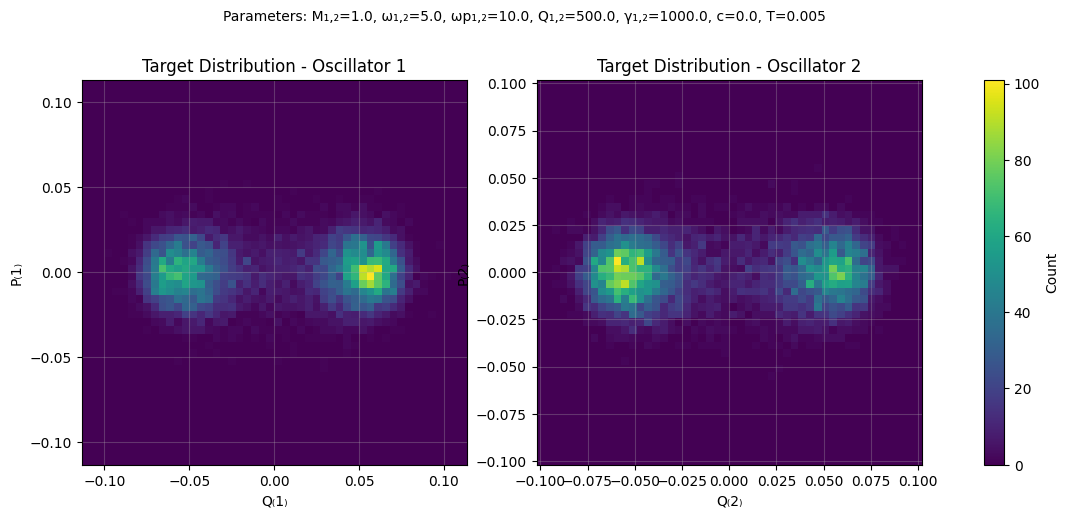

In [6]:
# Create figure with proper spacing for plots and colorbar
fig = plt.figure(figsize=(12, 5))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.2)

# Create subplots for both oscillators
ax_osc1 = fig.add_subplot(gs[0, 0])  # Left (Osc1)
ax_osc2 = fig.add_subplot(gs[0, 1])  # Right (Osc2)
cax = fig.add_subplot(gs[0, 2])      # Colorbar

# Calculate limits for each oscillator
q1_lim = max(abs(sde_samples_QP_target[:, 0].min()), abs(sde_samples_QP_target[:, 0].max()))
p1_lim = max(abs(sde_samples_QP_target[:, 1].min()), abs(sde_samples_QP_target[:, 1].max()))
q2_lim = max(abs(sde_samples_QP_target[:, 2].min()), abs(sde_samples_QP_target[:, 2].max()))
p2_lim = max(abs(sde_samples_QP_target[:, 3].min()), abs(sde_samples_QP_target[:, 3].max()))

lim1 = max(q1_lim, p1_lim) * 1.1  # Add 10% margin for oscillator 1
lim2 = max(q2_lim, p2_lim) * 1.1  # Add 10% margin for oscillator 2

# Plot distributions
bins = 50
range_lim1 = [[-lim1, lim1], [-lim1, lim1]]
range_lim2 = [[-lim2, lim2], [-lim2, lim2]]

# Target state plots
hist1 = ax_osc1.hist2d(sde_samples_QP_target[:, 0], 
                       sde_samples_QP_target[:, 1], 
                       bins=bins, cmap='viridis', range=range_lim1)
hist2 = ax_osc2.hist2d(sde_samples_QP_target[:, 2], 
                       sde_samples_QP_target[:, 3], 
                       bins=bins, cmap='viridis', range=range_lim2)

# Set properties for both axes
for ax, lim, osc_num in [(ax_osc1, lim1, 1), (ax_osc2, lim2, 2)]:
    ax.set_aspect('equal')
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel(f'Q₍{osc_num}₎')
    ax.set_ylabel(f'P₍{osc_num}₎')
    ax.set_title(f'Target Distribution - Oscillator {osc_num}')

# Add colorbar
plt.colorbar(hist1[3], cax=cax, label='Count')

# Compact parameter title
title = (f'Parameters: M₁,₂={M1}, ω₁,₂={w1}, ωp₁,₂={wp1}, '
         f'Q₁,₂={Q1}, γ₁,₂={gamma1}, c={c}, T={T}')
plt.suptitle(title, y=1.02, size=10)

plt.show()

#### Compute the analytical marginals of the target distribution; assuming a Boltzmann distribution --> do not agree!!

In [7]:
def Hamiltonian_BM(Q1, P1, Q2, P2, args):
    """Boltzmann-scaled Hamiltonian for two coupled oscillators"""
    return Hamiltonian(Q1, P1, Q2, P2, args)/(k_B * T/(M1*w1**2))

def make_normalized_distribution(Q_range, P_range):
    # Create 2D meshes for both oscillators
    Q1s, P1s, Q2s, P2s = jnp.meshgrid(Q_range, P_range, Q_range, P_range)

    # Compute log of unnormalized probabilities on the 4D grid
    log_unnorm_grid = -Hamiltonian_BM(Q1s, P1s, Q2s, P2s, args_target)

    # Flatten to compute log-sum-exp across all grid points
    log_unnorm_flat = log_unnorm_grid.ravel()
    logZ = jax.scipy.special.logsumexp(log_unnorm_flat)

    def BM_distribution(Q1, P1, Q2, P2):
        return jnp.exp(-Hamiltonian_BM(Q1, P1, Q2, P2, args_target) - logZ)

    return BM_distribution

BOUND = 0.1
# Define ranges (using smaller grid for 4D calculation to manage memory)
Q_range = jnp.linspace(-BOUND, BOUND, 100)
P_range = jnp.linspace(-BOUND, BOUND, 100)

BM_distribution = make_normalized_distribution(Q_range, P_range)

# Calculate marginal distributions for oscillator 1
def get_osc1_marginal(Q1, P1):
    """Integrate over oscillator 2's coordinates"""
    values = jnp.array([[BM_distribution(Q1, P1, Q2, P2) 
                        for Q2 in Q_range] 
                        for P2 in P_range])
    return jnp.sum(values) * (Q_range[1]-Q_range[0]) * (P_range[1]-P_range[0])

# Calculate marginal distributions for oscillator 2
def get_osc2_marginal(Q2, P2):
    """Integrate over oscillator 1's coordinates"""
    values = jnp.array([[BM_distribution(Q1, P1, Q2, P2) 
                        for Q1 in Q_range] 
                        for P1 in P_range])
    return jnp.sum(values) * (Q_range[1]-Q_range[0]) * (P_range[1]-P_range[0])

# Vectorize the marginal calculations
vmap_osc1 = jax.vmap(jax.vmap(get_osc1_marginal, in_axes=(None, 0)), in_axes=(0, None))
vmap_osc2 = jax.vmap(jax.vmap(get_osc2_marginal, in_axes=(None, 0)), in_axes=(0, None))

# Calculate distribution values
BM_distribution_values_osc1 = vmap_osc1(Q_range, P_range).T
BM_distribution_values_osc2 = vmap_osc2(Q_range, P_range).T

# Calculate marginals for each oscillator
BM_distribution_values_Q1_marginal = jnp.sum(BM_distribution_values_osc1, axis=0)
BM_distribution_values_P1_marginal = jnp.sum(BM_distribution_values_osc1, axis=1)
BM_distribution_values_Q2_marginal = jnp.sum(BM_distribution_values_osc2, axis=0)
BM_distribution_values_P2_marginal = jnp.sum(BM_distribution_values_osc2, axis=1)

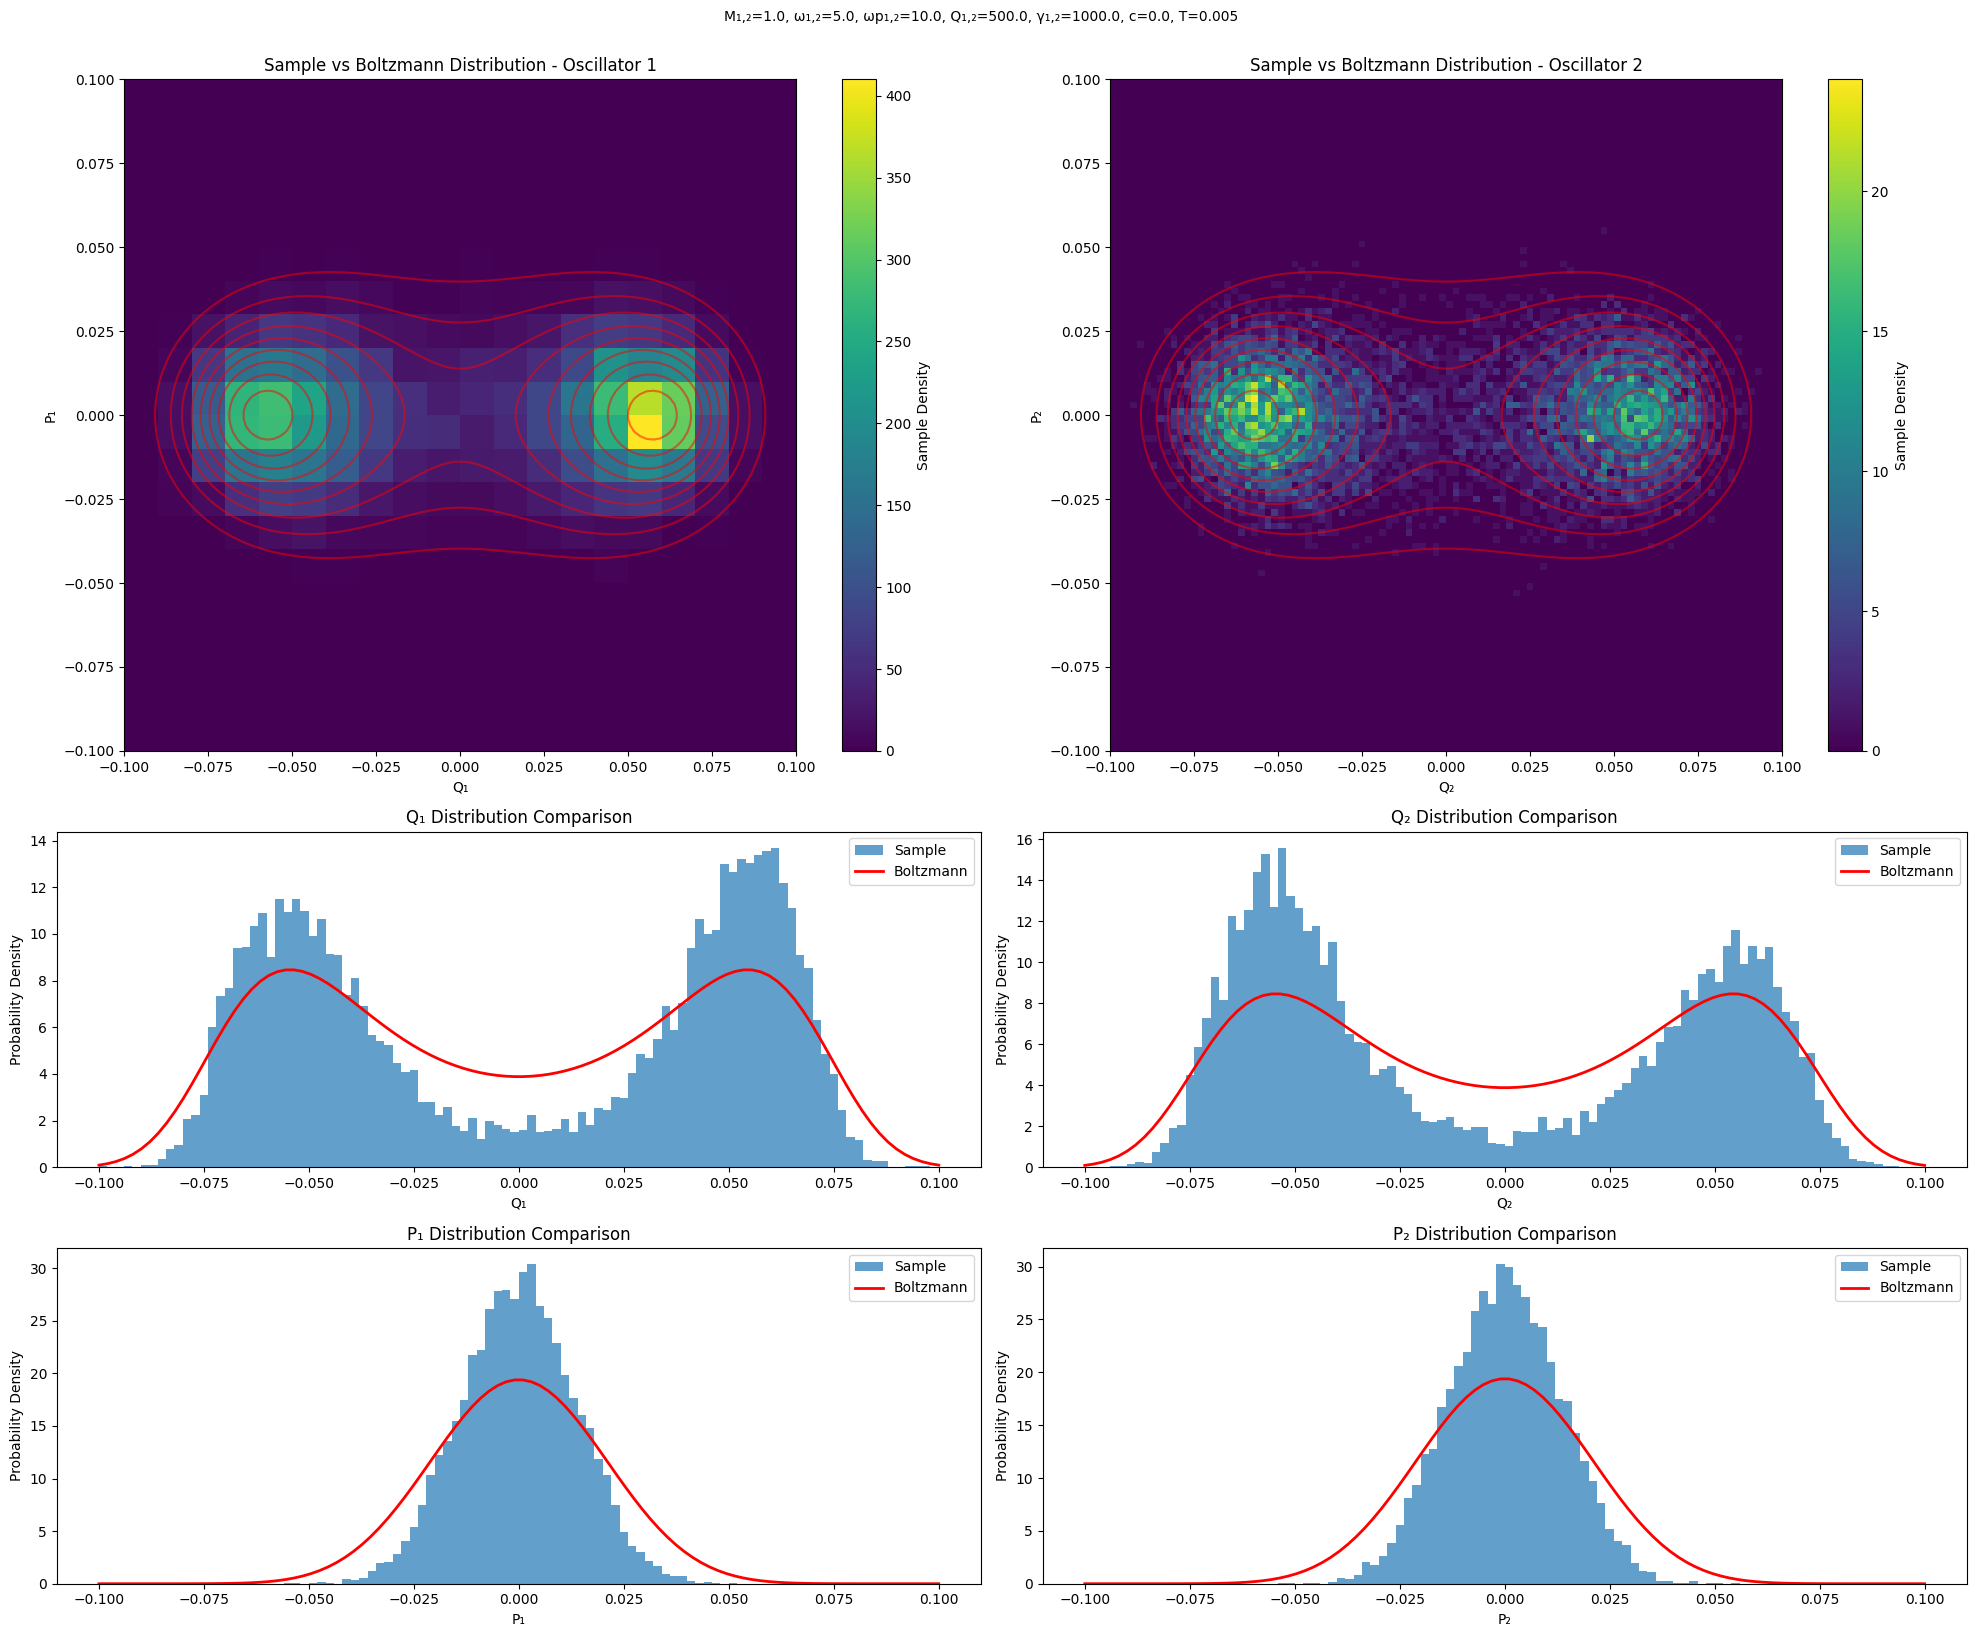

In [9]:
import numpy as np
# Create figure with a grid of subplots
fig = plt.figure(figsize=(20, 16))
gs = plt.GridSpec(3, 2, height_ratios=[2, 1, 1])

# Create meshgrid for contour plots
X, Y = np.meshgrid(Q_range, P_range)
n_bins = 100
# Top left: Phase space density plot of samples for oscillator 1
ax1 = fig.add_subplot(gs[0, 0])
h1 = ax1.hist2d(sde_samples_QP_target[:, 0], sde_samples_QP_target[:, 1], 
                bins=n_bins, range=[[-BOUND, BOUND], [-BOUND, BOUND]])
plt.colorbar(h1[3], ax=ax1, label='Sample Density')
# Add contour plot of analytical distribution for oscillator 1
ax1.contour(X, Y, BM_distribution_values_osc1, levels=10, colors='r', alpha=0.5)
ax1.set_aspect('equal')
ax1.set_xlabel('Q₁')
ax1.set_ylabel('P₁')
ax1.set_title('Sample vs Boltzmann Distribution - Oscillator 1')

# Top right: Phase space density plot of samples for oscillator 2
ax2 = fig.add_subplot(gs[0, 1])
h2 = ax2.hist2d(sde_samples_QP_target[:, 2], sde_samples_QP_target[:, 3], 
                bins=n_bins, range=[[-BOUND, BOUND], [-BOUND, BOUND]])
plt.colorbar(h2[3], ax=ax2, label='Sample Density')
# Add contour plot of analytical distribution for oscillator 2
ax2.contour(X, Y, BM_distribution_values_osc2, levels=10, colors='r', alpha=0.5)
ax2.set_aspect('equal')
ax2.set_xlabel('Q₂')
ax2.set_ylabel('P₂')
ax2.set_title('Sample vs Boltzmann Distribution - Oscillator 2')

# Middle row: Q distributions
# Q1 distribution
ax3 = fig.add_subplot(gs[1, 0])
hist_q1 = ax3.hist(sde_samples_QP_target[:, 0], bins=n_bins, density=True, alpha=0.7, 
                   label='Sample', range=[-BOUND, BOUND])
# Normalize the analytical curve to match histogram area
q1_norm = BM_distribution_values_Q1_marginal / (np.sum(BM_distribution_values_Q1_marginal) * (Q_range[1] - Q_range[0]))
ax3.plot(Q_range, q1_norm, 'r-', label='Boltzmann', linewidth=2)
ax3.set_xlabel('Q₁')
ax3.set_ylabel('Probability Density')
ax3.set_title('Q₁ Distribution Comparison')
ax3.legend()

# Q2 distribution
ax4 = fig.add_subplot(gs[1, 1])
hist_q2 = ax4.hist(sde_samples_QP_target[:, 2], bins=n_bins, density=True, alpha=0.7, 
                   label='Sample', range=[-BOUND, BOUND])
# Normalize the analytical curve to match histogram area
q2_norm = BM_distribution_values_Q2_marginal / (np.sum(BM_distribution_values_Q2_marginal) * (Q_range[1] - Q_range[0]))
ax4.plot(Q_range, q2_norm, 'r-', label='Boltzmann', linewidth=2)
ax4.set_xlabel('Q₂')
ax4.set_ylabel('Probability Density')
ax4.set_title('Q₂ Distribution Comparison')
ax4.legend()

# Bottom row: P distributions
# P1 distribution
ax5 = fig.add_subplot(gs[2, 0])
hist_p1 = ax5.hist(sde_samples_QP_target[:, 1], bins=n_bins, density=True, alpha=0.7, 
                   label='Sample', range=[-BOUND, BOUND])
# Normalize the analytical curve to match histogram area
p1_norm = BM_distribution_values_P1_marginal / (np.sum(BM_distribution_values_P1_marginal) * (P_range[1] - P_range[0]))
ax5.plot(P_range, p1_norm, 'r-', label='Boltzmann', linewidth=2)
ax5.set_xlabel('P₁')
ax5.set_ylabel('Probability Density')
ax5.set_title('P₁ Distribution Comparison')
ax5.legend()

# P2 distribution
ax6 = fig.add_subplot(gs[2, 1])
hist_p2 = ax6.hist(sde_samples_QP_target[:, 3], bins=n_bins, density=True, alpha=0.7, 
                   label='Sample', range=[-BOUND, BOUND])
# Normalize the analytical curve to match histogram area
p2_norm = BM_distribution_values_P2_marginal / (np.sum(BM_distribution_values_P2_marginal) * (P_range[1] - P_range[0]))
ax6.plot(P_range, p2_norm, 'r-', label='Boltzmann', linewidth=2)
ax6.set_xlabel('P₂')
ax6.set_ylabel('Probability Density')
ax6.set_title('P₂ Distribution Comparison')
ax6.legend()

plt.tight_layout()
# Add title with parameters
title = f'M₁,₂={M1}, ω₁,₂={w1}, ωp₁,₂={wp1}, Q₁,₂={Q1}, γ₁,₂={gamma1}, c={c}, T={T}'
plt.suptitle(title, y=1.02, size=10)

# Save the figure
# save_dir = "../out/UnderstandingDistribution/"
# os.makedirs(save_dir, exist_ok=True)
# filename = f'comparison_BM_2osc_Q{Q1}_T{T}_gamma{gamma1}_c{c}_wp{wp1}_periods{num_periods}.png'
# full_path = os.path.join(save_dir, filename)
# plt.savefig(full_path, bbox_inches='tight', dpi=300)
plt.show()